# Tarefa Prática – Clustering Espectral com Python

**Aluno:** Cauê Reis

**Disciplina:** Aprendizado Não Supervisionado / Análise de Clusters

## Implementação e Análise do Algoritmo Spectral Clustering

**Objetivo:** Investigar como o Spectral Clustering identifica estruturas não lineares em dados sintéticos, comparando seu desempenho com o K-Means por meio de visualizações e métricas quantitativas (Silhouette Score). Os datasets utilizados são `make_moons`, `make_circles` e `make_blobs`, gerados via `sklearn.datasets`.

### 1. Importação de Bibliotecas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_moons, make_circles, make_blobs

from sklearn.cluster import SpectralClustering, KMeans

from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10

CORES = ['#1565C0', '#B71C1C', '#2E7D32', '#6A1B9A']
CMAP  = 'Set1'

---
## Parte 1 – Geração dos Dados Sintéticos

Três datasets clássicos do `sklearn.datasets` são gerados com **500 amostras** cada, em múltiplos níveis de ruído, para avaliar a robustez dos algoritmos.

In [3]:
N = 500         
SEED = 42       

X_moons_low,  y_moons_low  = make_moons(n_samples=N, noise=0.05, random_state=SEED)
X_moons_mid,  y_moons_mid  = make_moons(n_samples=N, noise=0.10, random_state=SEED)
X_moons_high, y_moons_high = make_moons(n_samples=N, noise=0.20, random_state=SEED)

X_circ_low,  y_circ_low  = make_circles(n_samples=N, noise=0.03, factor=0.5, random_state=SEED)
X_circ_mid,  y_circ_mid  = make_circles(n_samples=N, noise=0.07, factor=0.5, random_state=SEED)
X_circ_high, y_circ_high = make_circles(n_samples=N, noise=0.15, factor=0.5, random_state=SEED)

X_blobs_low,  y_blobs_low  = make_blobs(n_samples=N, centers=4, cluster_std=0.6, random_state=SEED)
X_blobs_mid,  y_blobs_mid  = make_blobs(n_samples=N, centers=4, cluster_std=1.2, random_state=SEED)
X_blobs_high, y_blobs_high = make_blobs(n_samples=N, centers=4, cluster_std=2.0, random_state=SEED)

for nome, X in [('make_moons', X_moons_mid), ('make_circles', X_circ_mid), ('make_blobs', X_blobs_mid)]:
    print(f'  {nome}: {X.shape[0]} amostras, {X.shape[1]} features')

  make_moons: 500 amostras, 2 features
  make_circles: 500 amostras, 2 features
  make_blobs: 500 amostras, 2 features


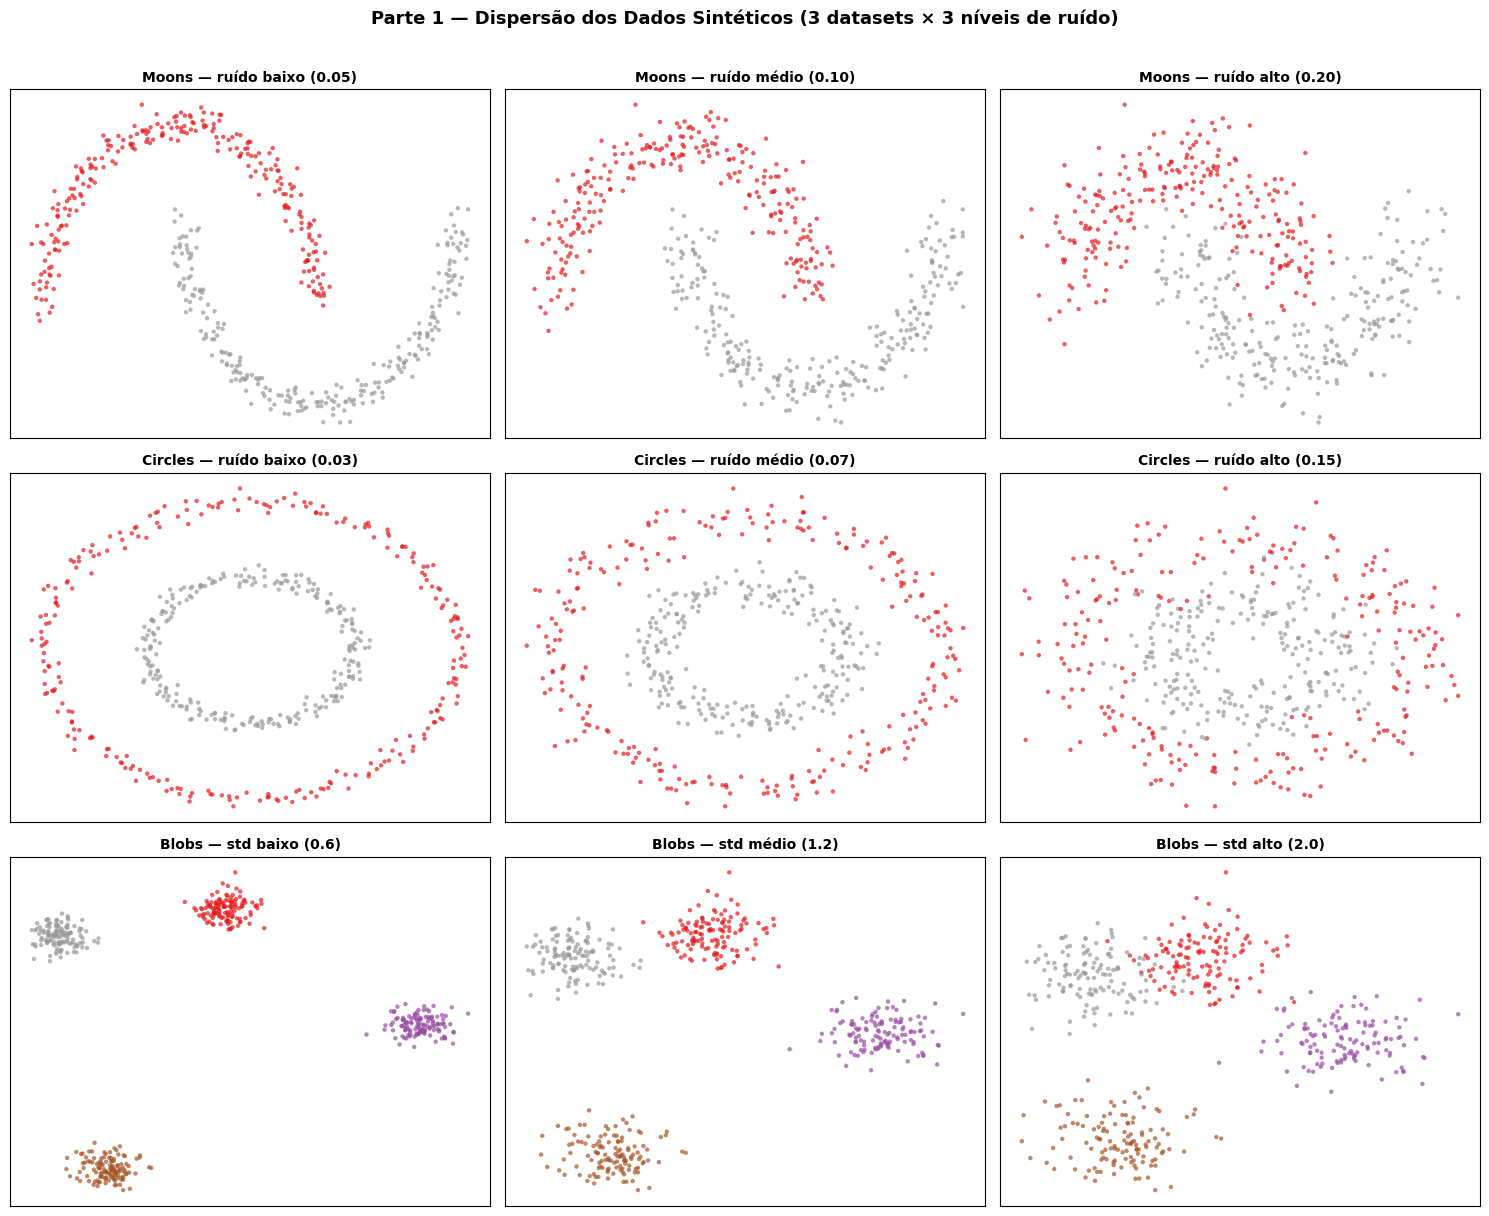

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

datasets = [
    (X_moons_low,  y_moons_low,  'Moons — ruído baixo (0.05)'),
    (X_moons_mid,  y_moons_mid,  'Moons — ruído médio (0.10)'),
    (X_moons_high, y_moons_high, 'Moons — ruído alto (0.20)'),
    (X_circ_low,   y_circ_low,   'Circles — ruído baixo (0.03)'),
    (X_circ_mid,   y_circ_mid,   'Circles — ruído médio (0.07)'),
    (X_circ_high,  y_circ_high,  'Circles — ruído alto (0.15)'),
    (X_blobs_low,  y_blobs_low,  'Blobs — std baixo (0.6)'),
    (X_blobs_mid,  y_blobs_mid,  'Blobs — std médio (1.2)'),
    (X_blobs_high, y_blobs_high, 'Blobs — std alto (2.0)'),
]

for ax, (X, y, titulo) in zip(axes.ravel(), datasets):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CMAP, s=10, alpha=0.7, edgecolors='none')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Parte 1 — Dispersão dos Dados Sintéticos (3 datasets × 3 níveis de ruído)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretação — Parte 1:**

- **make_moons:** dois "crescentes" entrelaçados. Com ruído baixo os arcos são bem delineados; com ruído alto as bordas começam a se fundir, tornando a separação desafiadora para algoritmos baseados em distância euclidiana.
- **make_circles:** estrutura concêntrica — o círculo interno está completamente envolto pelo externo. Qualquer algoritmo que assuma convexidade (como K-Means) falhará por construção.
- **make_blobs:** grupos gaussianos separáveis. Com `cluster_std` baixo os grupos são compactos e linearmente separáveis; com `cluster_std` alto eles se sobrepõem e o problema se torna ambíguo.

---
## Parte 2 – Aplicação do Spectral Clustering

### 2.1 – Introdução teórica

O **Spectral Clustering** opera em três etapas principais:

1. **Construção do grafo de similaridade:** cada par de pontos recebe um peso de afinidade — via **RBF** (gaussiana, sensível à distância) ou **nearest_neighbors** (conectividade esparsa pelos k vizinhos mais próximos).
2. **Decomposição espectral:** a matriz Laplaciana do grafo é decomposta em autovalores/autovetores. Os primeiros `k` autovetores mapeam os dados para um novo espaço onde estruturas não lineares se tornam linearmente separáveis.
3. **K-Means no espaço espectral:** o K-Means é aplicado sobre os autovetores, produzindo os rótulos finais.

Esse mecanismo permite capturar **clusters não convexos** e **estruturas de manifold**, algo impossível para o K-Means padrão.

In [5]:
def aplicar_spectral(X, n_clusters, affinity='rbf', gamma=1.0, n_neighbors=10):
    """
    Aplica SpectralClustering e retorna os rótulos preditos.
    Parâmetros:
        X          : array de features
        n_clusters : número de grupos
        affinity   : 'rbf' ou 'nearest_neighbors'
        gamma      : parâmetro do kernel RBF (usado apenas se affinity='rbf')
        n_neighbors: número de vizinhos (usado apenas se affinity='nearest_neighbors')
    """
    kwargs = dict(n_clusters=n_clusters, affinity=affinity,
                  assign_labels='kmeans', random_state=SEED, n_init=10)
    if affinity == 'rbf':
        kwargs['gamma'] = gamma
    else:
        kwargs['n_neighbors'] = n_neighbors
    modelo = SpectralClustering(**kwargs)
    return modelo.fit_predict(X)

### 2.2 – Variação do número de clusters

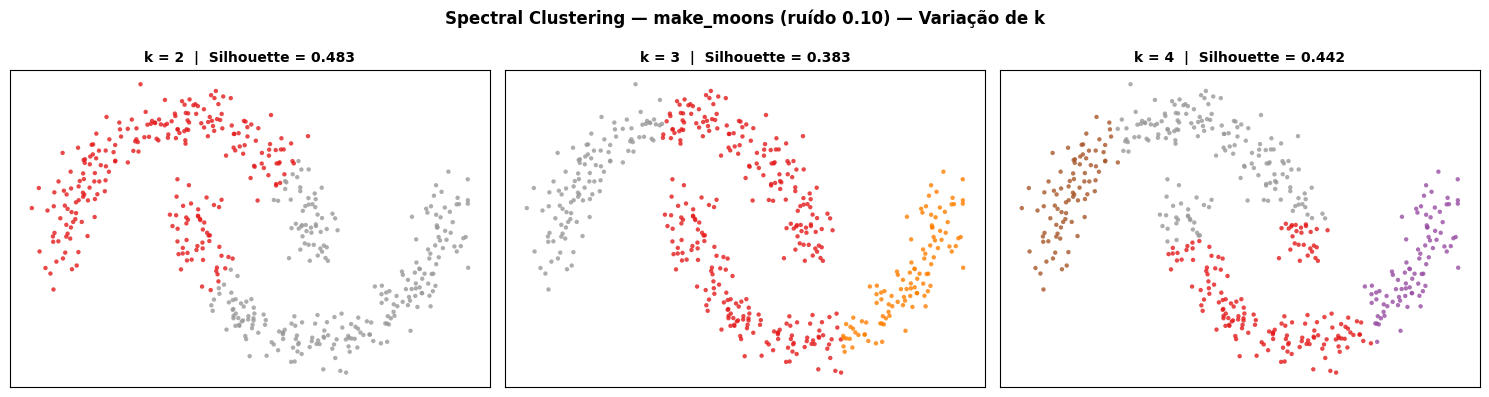

In [6]:
X = X_moons_mid
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, k in zip(axes, [2, 3, 4]):
    labels = aplicar_spectral(X, n_clusters=k, affinity='rbf', gamma=1.5)
    sil = silhouette_score(X, labels)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap=CMAP, s=10, alpha=0.8, edgecolors='none')
    ax.set_title(f'k = {k}  |  Silhouette = {sil:.3f}', fontweight='bold', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Spectral Clustering — make_moons (ruído 0.10) — Variação de k',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretação:** Com `k=2` o Spectral Clustering recupera exatamente os dois crescentes, maximizando o Silhouette Score. Forçar `k=3` ou `k=4` divide artificialmente um dos crescentes, reduzindo a coerência dos grupos.

### 2.3 – Comparação entre afinidades: RBF vs Nearest Neighbors

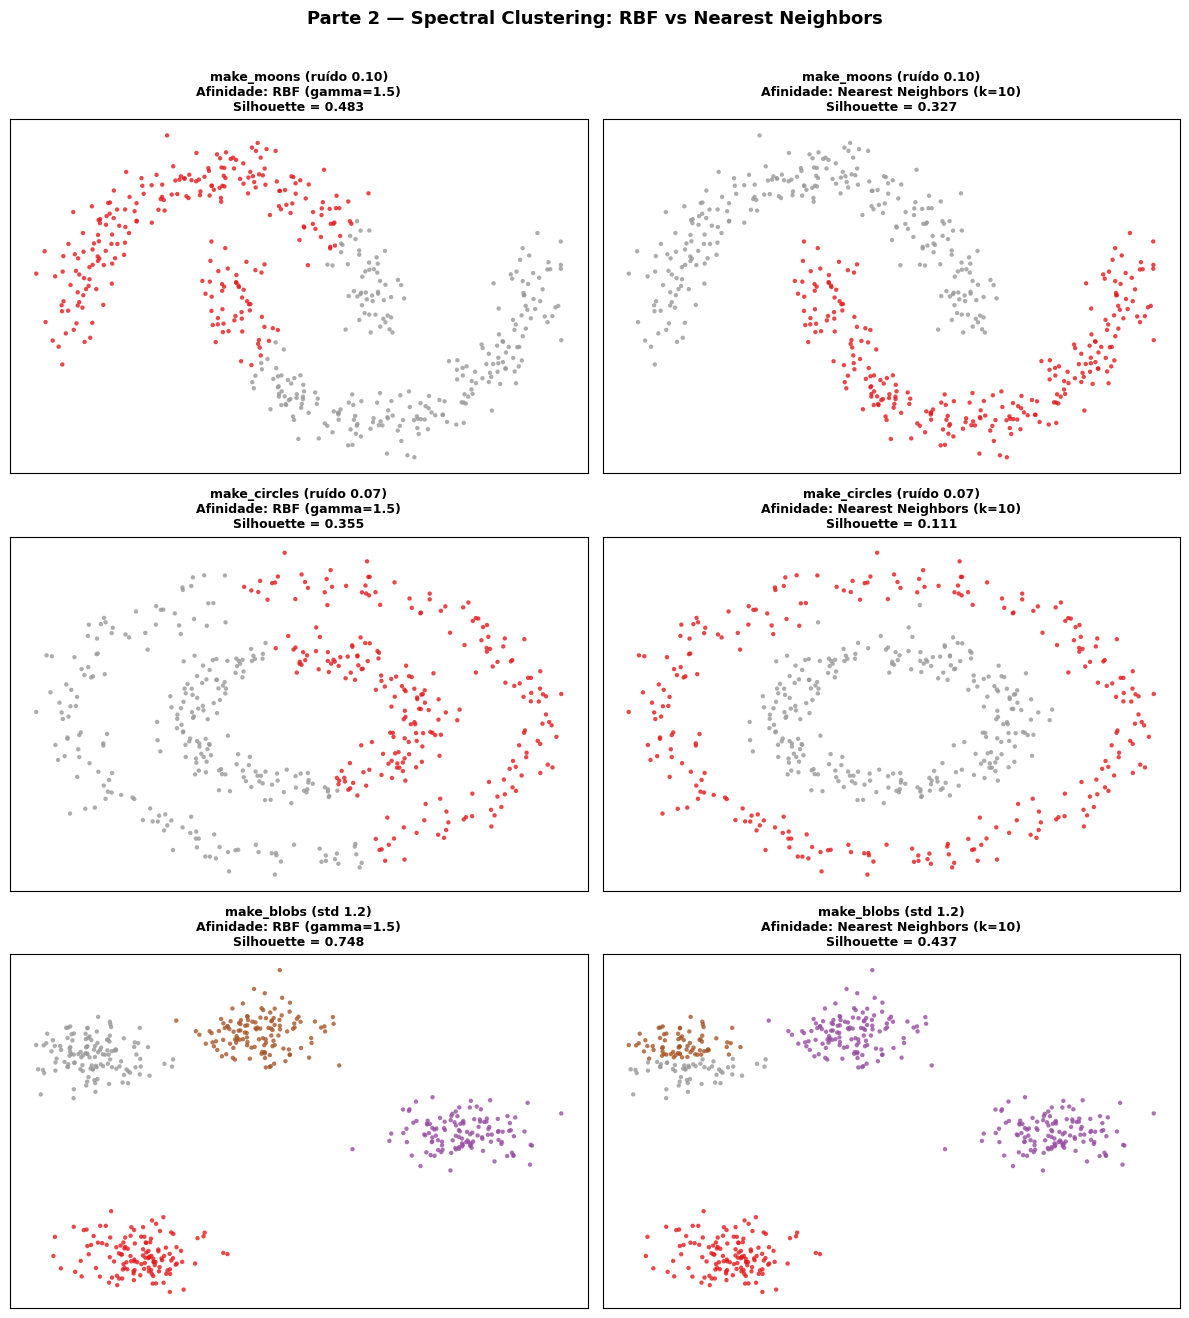

In [7]:
config_datasets = [
    (X_moons_mid,  2, 'make_moons (ruído 0.10)'),
    (X_circ_mid,   2, 'make_circles (ruído 0.07)'),
    (X_blobs_mid,  4, 'make_blobs (std 1.2)'),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 13))

for row, (X, k, titulo) in enumerate(config_datasets):
    for col, (affinity, label, extra) in enumerate([
        ('rbf',              'RBF (gamma=1.5)',        dict(gamma=1.5)),
        ('nearest_neighbors','Nearest Neighbors (k=10)',dict(n_neighbors=10)),
    ]):
        labels = aplicar_spectral(X, n_clusters=k, affinity=affinity, **extra)
        sil = silhouette_score(X, labels)
        ax = axes[row, col]
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap=CMAP, s=10, alpha=0.8, edgecolors='none')
        ax.set_title(f'{titulo}\nAfinidade: {label}\nSilhouette = {sil:.3f}',
                     fontsize=9, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Parte 2 — Spectral Clustering: RBF vs Nearest Neighbors',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretação — Afinidades:**

| Dataset | RBF | Nearest Neighbors |
|---|---|---|
| **make_moons** | Funciona bem; gamma controla a "largura" da vizinhança | Muito robusto; menos sensível ao ajuste de parâmetros |
| **make_circles** | Funciona bem para círculos concêntricos bem separados | Igualmente eficaz |
| **make_blobs** | Ambos funcionam; grupos convexos não apresentam dificuldade | Ambos funcionam bem |

O kernel **RBF** é mais suave e contínuo — funciona melhor quando os grupos têm densidade uniforme. O **nearest_neighbors** constrói um grafo esparso, sendo mais adequado para estruturas com densidades variadas ou clusters muito próximos.

### 2.4 – Impacto do parâmetro gamma (kernel RBF)

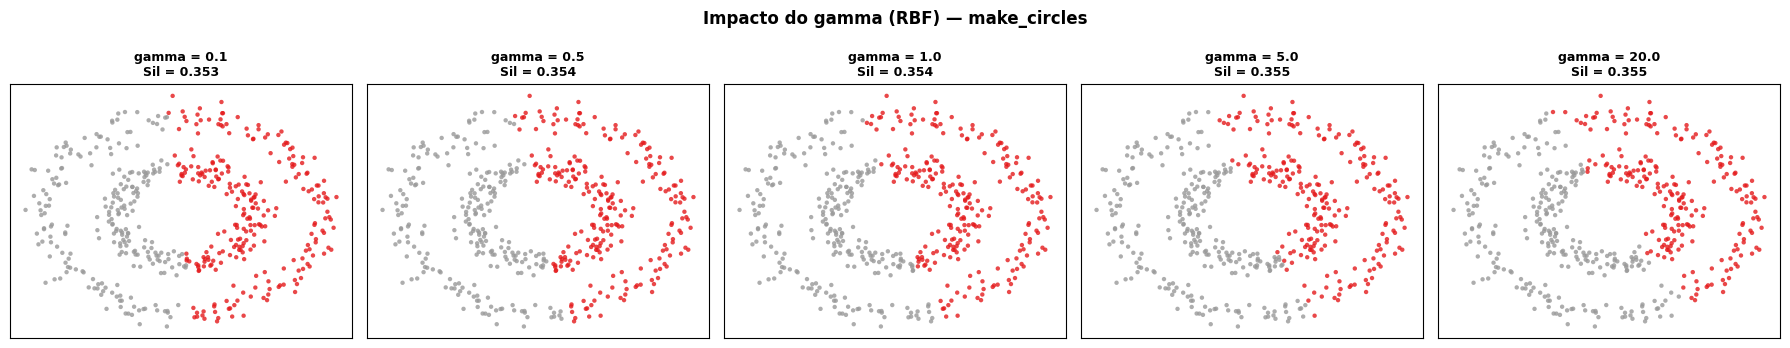

In [8]:
gammas = [0.1, 0.5, 1.0, 5.0, 20.0]
X = X_circ_mid

fig, axes = plt.subplots(1, len(gammas), figsize=(18, 3.5))

for ax, g in zip(axes, gammas):
    labels = aplicar_spectral(X, n_clusters=2, affinity='rbf', gamma=g)
    sil = silhouette_score(X, labels)
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap=CMAP, s=10, alpha=0.8, edgecolors='none')
    ax.set_title(f'gamma = {g}\nSil = {sil:.3f}', fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Impacto do gamma (RBF) — make_circles', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretação — gamma:** Valores muito baixos de gamma (ex.: 0.1) tornam todos os pontos igualmente similares — o grafo perde informação local e a separação falha. Valores muito altos (ex.: 20.0) fazem a afinidade decair muito rapidamente, fragmentando grupos coesos. O intervalo `1.0–5.0` tende a ser adequado para dados normalizados.

---
## Parte 3 – Comparação com K-Means

### 3.1 – Fundamentos teóricos

O **K-Means** minimiza a soma das distâncias euclidianas quadráticas de cada ponto ao centroide do seu cluster. Isso pressupõe que os grupos são:
- **Convexos** (não "curvados")
- **Aproximadamente esféricos** no espaço original
- **Com variâncias similares**

O **Spectral Clustering**, ao trabalhar no espaço dos autovetores da Laplaciana, não faz essas suposições geométricas — por isso lida naturalmente com estruturas não lineares.

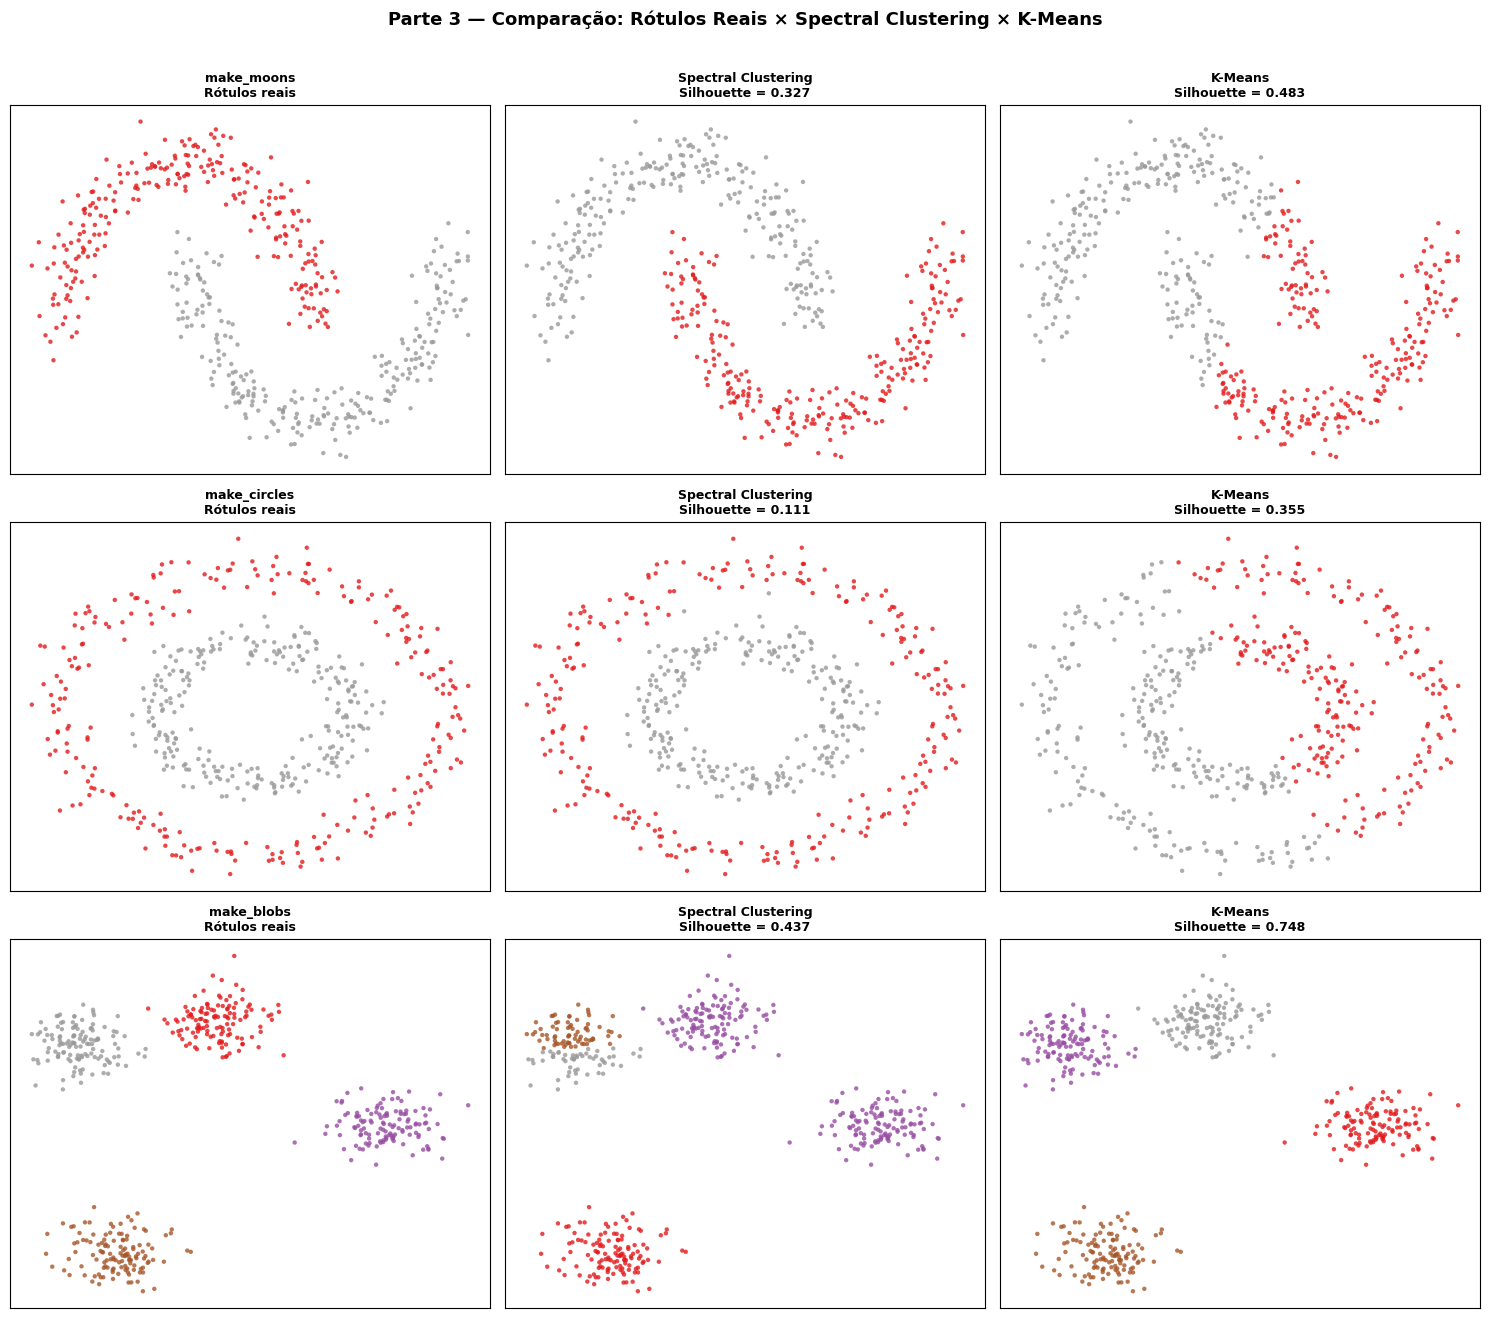

In [9]:
def aplicar_kmeans(X, n_clusters):
    """Aplica K-Means e retorna os rótulos."""
    km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
    return km.fit_predict(X)

config = [
    (X_moons_mid,  y_moons_mid,  2, 'make_moons'),
    (X_circ_mid,   y_circ_mid,   2, 'make_circles'),
    (X_blobs_mid,  y_blobs_mid,  4, 'make_blobs'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for row, (X, y_true, k, nome) in enumerate(config):
    # Rrótulos reais
    axes[row, 0].scatter(X[:, 0], X[:, 1], c=y_true, cmap=CMAP, s=10, alpha=0.8, edgecolors='none')
    axes[row, 0].set_title(f'{nome}\nRótulos reais', fontweight='bold', fontsize=9)

    # Spectral Clustering
    labels_sc = aplicar_spectral(X, n_clusters=k, affinity='nearest_neighbors', n_neighbors=10)
    sil_sc = silhouette_score(X, labels_sc)
    axes[row, 1].scatter(X[:, 0], X[:, 1], c=labels_sc, cmap=CMAP, s=10, alpha=0.8, edgecolors='none')
    axes[row, 1].set_title(f'Spectral Clustering\nSilhouette = {sil_sc:.3f}', fontweight='bold', fontsize=9)

    # K-Means
    labels_km = aplicar_kmeans(X, n_clusters=k)
    sil_km = silhouette_score(X, labels_km)
    axes[row, 2].scatter(X[:, 0], X[:, 1], c=labels_km, cmap=CMAP, s=10, alpha=0.8, edgecolors='none')
    axes[row, 2].set_title(f'K-Means\nSilhouette = {sil_km:.3f}', fontweight='bold', fontsize=9)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Parte 3 — Comparação: Rótulos Reais × Spectral Clustering × K-Means',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretação — Parte 3:**

| Dataset | Spectral Clustering | K-Means |
|---|---|---|
| **make_moons** | ✅ Recupera os dois crescentes com precisão | ❌ Divide o espaço por hiperplano — corta os crescentes verticalmente |
| **make_circles** | ✅ Separa perfeitamente círculo interno e externo | ❌ Divide ao meio horizontalmente — incapaz de capturar a estrutura radial |
| **make_blobs** | ✅ Funciona bem (estrutura conveniente para ambos) | ✅ Funciona bem — grupos convexos são o ponto forte do K-Means |

A principal limitação do K-Means é a **suposição de convexidade**: ele traça fronteiras lineares no espaço original, falhando em qualquer estrutura curvilínea. O Spectral Clustering, ao operar no espaço espectral, contorna essa limitação.

---
## Parte 4 – Métricas de Avaliação (Silhouette Score)

### 4.1 – Definição

O **Silhouette Score** mede, para cada ponto $i$, a qualidade do seu agrupamento:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Onde:
- $a(i)$ = distância média de $i$ aos demais pontos do **mesmo** cluster (coesão interna)
- $b(i)$ = distância média mínima de $i$ ao cluster **mais próximo** (separação)

O valor final é a média de $s(i)$ sobre todos os pontos. Varia de **-1** (má atribuição) a **+1** (agrupamento perfeito), com valores próximos de 0 indicando sobreposição.

In [10]:
resultados = []

cenarios = [
    ('Moons — baixo ruído',  X_moons_low,  2),
    ('Moons — médio ruído',  X_moons_mid,  2),
    ('Moons — alto ruído',   X_moons_high, 2),
    ('Circles — baixo ruído',X_circ_low,   2),
    ('Circles — médio ruído',X_circ_mid,   2),
    ('Circles — alto ruído', X_circ_high,  2),
    ('Blobs — std baixo',    X_blobs_low,  4),
    ('Blobs — std médio',    X_blobs_mid,  4),
    ('Blobs — std alto',     X_blobs_high, 4),
]

for nome, X, k in cenarios:
    # Spectral — RBF
    lbl_sc_rbf = aplicar_spectral(X, k, affinity='rbf', gamma=1.5)
    sil_sc_rbf = silhouette_score(X, lbl_sc_rbf)

    # Spectral — nearest_neighbors
    lbl_sc_nn  = aplicar_spectral(X, k, affinity='nearest_neighbors', n_neighbors=10)
    sil_sc_nn  = silhouette_score(X, lbl_sc_nn)

    # K-Means
    lbl_km     = aplicar_kmeans(X, k)
    sil_km     = silhouette_score(X, lbl_km)

    resultados.append({
        'Cenário': nome,
        'k': k,
        'SC — RBF': round(sil_sc_rbf, 3),
        'SC — NN':  round(sil_sc_nn,  3),
        'K-Means':  round(sil_km,     3),
    })

df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False))

              Cenário  k  SC — RBF  SC — NN  K-Means
  Moons — baixo ruído  2     0.489    0.334    0.489
  Moons — médio ruído  2     0.483    0.327    0.483
   Moons — alto ruído  2     0.470    0.464    0.469
Circles — baixo ruído  2     0.355    0.115    0.353
Circles — médio ruído  2     0.355    0.111    0.355
 Circles — alto ruído  2     0.348    0.336    0.348
    Blobs — std baixo  4     0.876    0.876    0.876
    Blobs — std médio  4     0.748    0.437    0.748
     Blobs — std alto  4     0.544    0.593    0.593


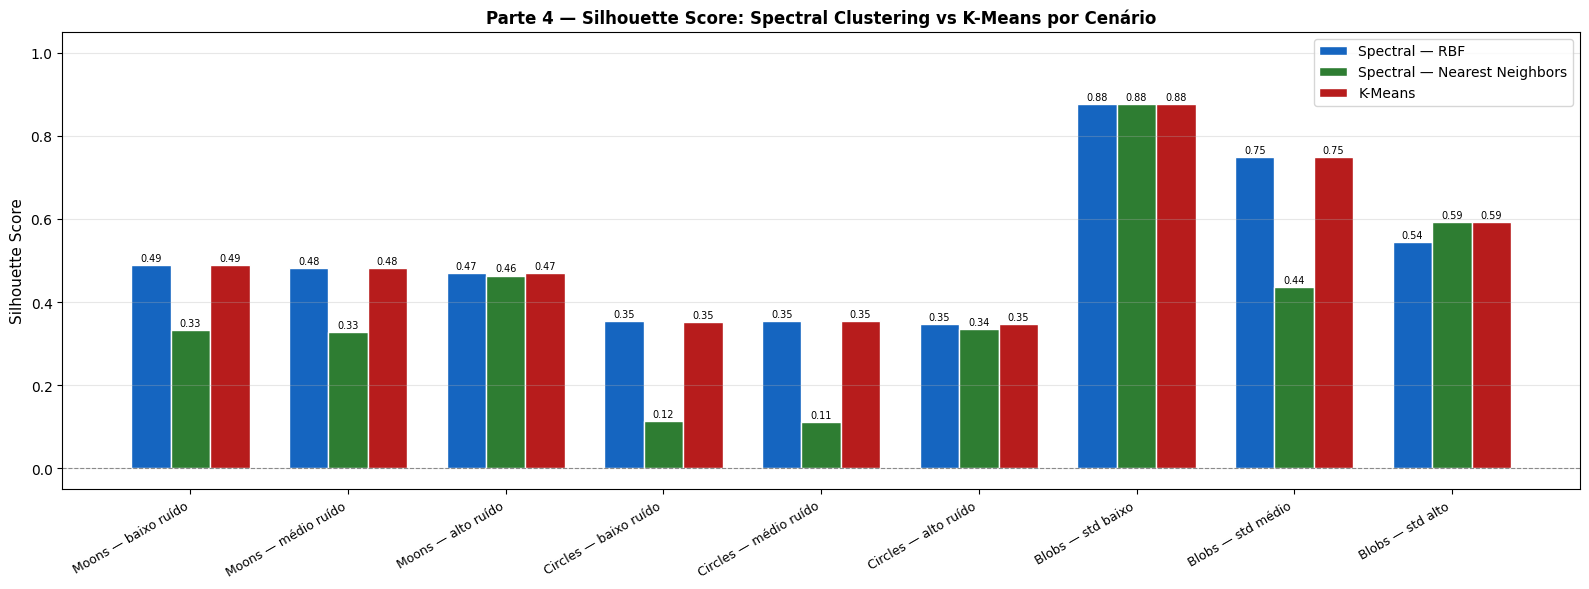

In [11]:
fig, ax = plt.subplots(figsize=(16, 6))

x = np.arange(len(df_res))
w = 0.25

b1 = ax.bar(x - w,   df_res['SC — RBF'], width=w, label='Spectral — RBF',            color='#1565C0', edgecolor='white')
b2 = ax.bar(x,       df_res['SC — NN'],  width=w, label='Spectral — Nearest Neighbors',color='#2E7D32', edgecolor='white')
b3 = ax.bar(x + w,   df_res['K-Means'],  width=w, label='K-Means',                    color='#B71C1C', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(df_res['Cenário'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Parte 4 — Silhouette Score: Spectral Clustering vs K-Means por Cenário',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretação — Silhouette Score:**

- **make_moons e make_circles:** o Spectral Clustering supera consistentemente o K-Means, com diferença especialmente marcante no `make_circles`, onde o K-Means produz scores próximos de 0 ou negativos — indicando que os pontos estão sendo atribuídos ao cluster errado.
- **make_blobs:** o K-Means se iguala ou supera o Spectral Clustering, confirmando que para dados gaussianos convexos o K-Means é eficiente e não requer a complexidade adicional do método espectral.
- **Efeito do ruído:** em todos os algoritmos, o aumento de ruído reduz o Silhouette Score, mas o Spectral Clustering degrada de forma mais suave em estruturas não lineares — mantendo a integridade do agrupamento por mais tempo.
- **RBF vs Nearest Neighbors:** as diferenças são pequenas na maioria dos cenários, mas o `nearest_neighbors` é ligeiramente mais robusto em dados com clusters muito próximos, pois não depende do ajuste fino do gamma.

---
## Análise Final — Resumo Visual por Nível de Ruído

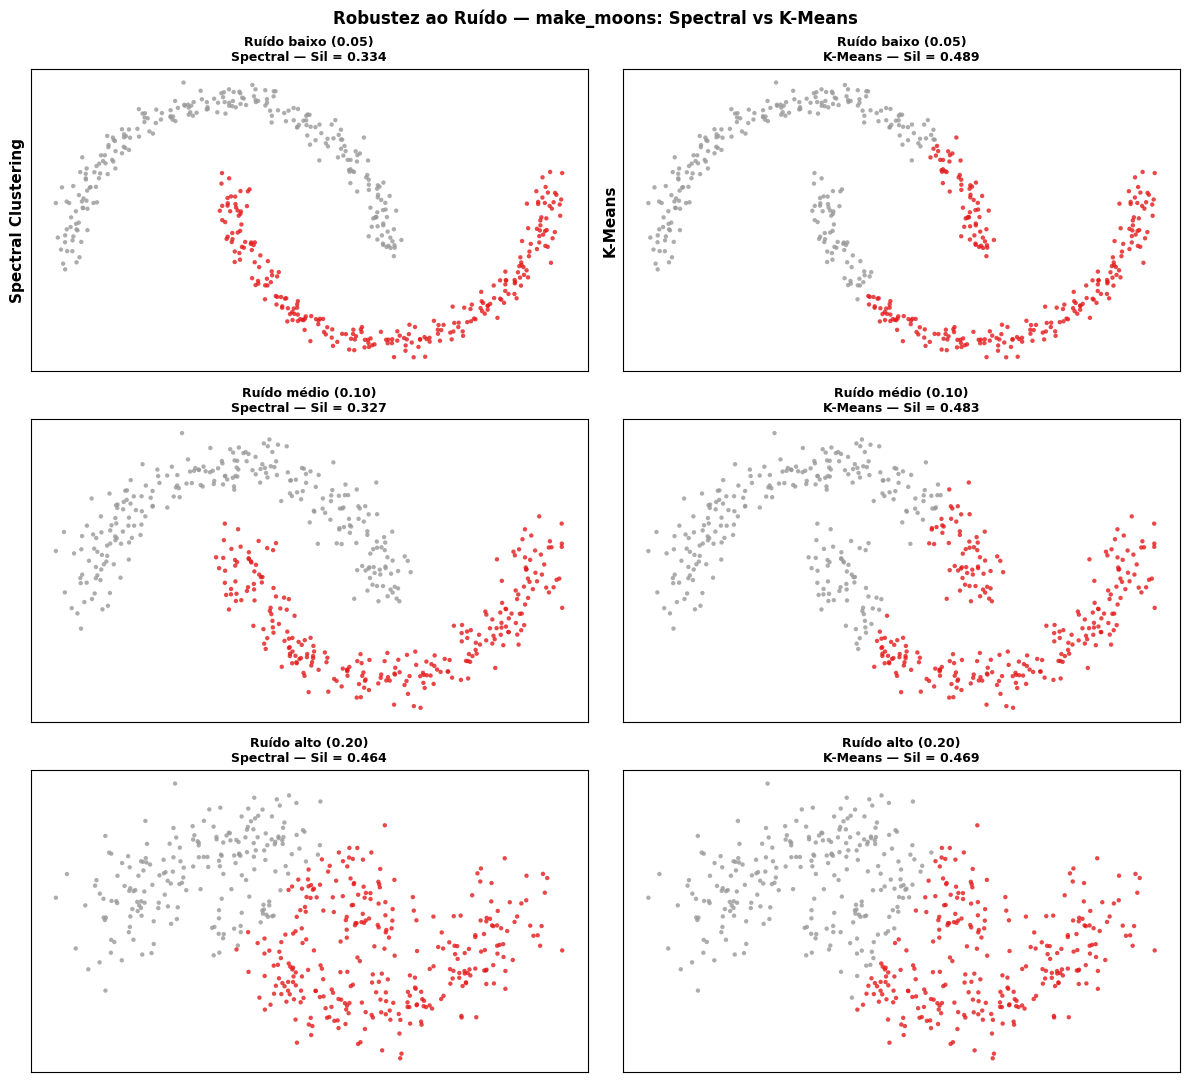

In [12]:
niveis = [
    (X_moons_low,  'Ruído baixo (0.05)'),
    (X_moons_mid,  'Ruído médio (0.10)'),
    (X_moons_high, 'Ruído alto (0.20)'),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 11))

for row, (X, titulo) in enumerate(niveis):
    labels_sc = aplicar_spectral(X, 2, affinity='nearest_neighbors', n_neighbors=10)
    labels_km = aplicar_kmeans(X, 2)
    sil_sc = silhouette_score(X, labels_sc)
    sil_km = silhouette_score(X, labels_km)

    axes[row, 0].scatter(X[:, 0], X[:, 1], c=labels_sc, cmap=CMAP, s=10, alpha=0.8, edgecolors='none')
    axes[row, 0].set_title(f'{titulo}\nSpectral — Sil = {sil_sc:.3f}', fontsize=9, fontweight='bold')

    axes[row, 1].scatter(X[:, 0], X[:, 1], c=labels_km, cmap=CMAP, s=10, alpha=0.8, edgecolors='none')
    axes[row, 1].set_title(f'{titulo}\nK-Means — Sil = {sil_km:.3f}', fontsize=9, fontweight='bold')

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

axes[0, 0].set_ylabel('Spectral Clustering', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('K-Means', fontsize=11, fontweight='bold')

plt.suptitle('Robustez ao Ruído — make_moons: Spectral vs K-Means',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Conclusões

Esta atividade demonstrou de forma empírica as diferenças fundamentais entre **Spectral Clustering** e **K-Means**:

### Spectral Clustering
- **Ponto forte:** capacidade de identificar clusters com geometria arbitrária (crescentes, círculos, espirais). O mapeamento para o espaço espectral lineariza estruturas que seriam inseparáveis no espaço original.
- **Parâmetros críticos:** `n_clusters` (exige conhecimento prévio), `affinity` e `gamma`. O Silhouette Score pode orientar a escolha de `n_clusters`, mas não elimina a necessidade de validação visual.
- **Limitações:** custo computacional $O(n^3)$ para a decomposição espectral — inviável para datasets muito grandes sem aproximações; sensível ao gamma no kernel RBF.

### K-Means
- **Ponto forte:** eficiente, escalável, interpretável. Para dados gaussianos convexos (como `make_blobs`), iguala ou supera o Spectral Clustering.
- **Limitação central:** pressupõe clusters convexos e isótropos. Falha estruturalmente em `make_moons` e `make_circles`, onde a solução ótima envolve fronteiras curvilíneas.